<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%204/mnist_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Assembling the MLP

**Goal:** Stack the building blocks into a complete neural network that can run a full forward and backward pass — the framework that will train on MNIST.

Everything here rests on one design idea: **every layer shares the same interface** — `forward(X)` and `backward(dZ)`. Because `Dense`, `Activation`, and the loss all speak this same language, the `MLP` can chain them without knowing what each one is. This is exactly how PyTorch's `nn.Sequential` works internally.

| Component | forward | backward |
|---|---|---|
| `Dense` | `Z = XW + b` | returns `dX`, stores `dW`, `db` |
| `Activation` (ReLU) | `max(0, X)` | multiplies incoming grad by ReLU' |
| `SoftmaxCrossEntropy` | scalar loss | returns the `(p − y)` starting gradient |
| `MLP` | loops layers forward | loops layers in reverse |

---

## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

## Activation Functions & Softmax

The vectorized helpers from the previous notebook. `softmax` is batched (operates per-row via `axis=1`) with the subtract-the-max stability trick.

In [2]:
def ReLU(x):
  return np.maximum(0, x)

def ReLU_deriv(x):
  return (x > 0).astype(float)

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
  return sigmoid(z) * (1 - sigmoid(z))

def tanh(x):
  return np.tanh(x)

def tanh_deriv(x):
  o = tanh(x)
  return 1 - o**2

In [3]:
def softmax(data):
    # Subtract each row's max for numerical stability (result is unchanged).
    shifted = data - np.max(data, axis=1, keepdims=True)
    e = np.exp(shifted)
    # Normalize each row so it sums to 1.
    return e / np.sum(e, axis=1, keepdims=True)

---
## 1. The Dense Layer

The fully-connected layer: $Z = XW + b$. It **caches `X`** in the forward pass (needed for the backward pass) and computes three gradients on the way back:

$$dW = X^T dZ \qquad db = \sum_{\text{rows}} dZ \qquad dX = dZ\, W^T$$

- `dW`, `db` — stored on the layer; the training loop will use them to update `W` and `b`
- `dX` — **returned**, to become the previous layer's incoming gradient

Weights use **He initialization** (`randn * sqrt(2/nin)`), which keeps signal variance stable through ReLU layers.

In [4]:
class Dense:
  def __init__(self, nin, nout):
    self.nin = nin
    self.nout = nout

    self.W = np.random.randn(nin, nout) * np.sqrt(2/nin)
    self.b = np.zeros((1, nout))

  def forward(self, X):
    self.X = X # Cache X because it is needed for backward pass
    Z = np.dot(X, self.W) + self.b

    return Z

  def backward(self, dZ):
    X = self.X

    self.dW = np.dot(X.T, dZ)
    self.db = np.sum(dZ, axis=0, keepdims=True)

    self.dX = np.dot(dZ, self.W.T)

    return self.dX

---
## 2. The Activation Layer (ReLU)

ReLU applies `max(0, X)` forward. Its backward follows the universal pattern from micrograd — **local derivative times incoming gradient**:

$$dX = \text{ReLU}'(X) \cdot dZ$$

Note the elegant symmetry: ReLU's forward zeros out negative inputs, and its backward zeros out the gradient wherever the input was negative. **Gradient only flows back through the units that were active on the forward pass.** Like Dense, it caches its input so backward can evaluate the derivative at the right point.

In [5]:
class Activation: ### ReLU Activation
  def forward(self, X):
    self.X = X
    return np.maximum(0, X)

  def backward(self, dZ):
    relu_derivative = (self.X > 0).astype(float)
    return relu_derivative * dZ # Gradient * Local Derivative

---
## 3. Softmax + Cross-Entropy Loss

This combines the final softmax with the categorical cross-entropy loss. For $K$ classes with one-hot label $y$ and predicted probabilities $p = \text{softmax}(\text{logits})$:

$$L = -\sum_k y_k \log(p_k)$$

Because $y$ is one-hot, only the true class's term survives — the loss is $-\log(p_{\text{true}})$, averaged over the batch.

### The clean gradient
The gradient of softmax + cross-entropy w.r.t. the logits is the same beautiful form we derived for binary logistic regression, now vectorized over all classes:

$$\frac{\partial L}{\partial \text{logits}} = \frac{p - y}{n}$$

This `(p − y)` is the **starting gradient** that kicks off the entire backward chain. (The `+1e-9` inside the log guards against `log(0)`.)

In [6]:
class SoftmaxCrossEntropy:
  def forward(self, logits, y_true):
    self.probs = softmax(logits)
    self.y_true = y_true

    n = logits.shape[0]
    loss = -np.sum(y_true * np.log(self.probs + 1e-9)) / n   # +1e-9 avoids log(0)
    return loss

  def backward(self):
    n = self.y_true.shape[0]
    return (self.probs - self.y_true) / n

---
## 4. The MLP — Chaining It All Together

The network holds a **list of layers** and chains them. The whole thing is tiny because each layer already knows how to do its own forward and backward:

- **`forward`** walks the layers in order, feeding each one's output into the next (`X = layer.forward(X)`).
- **`backward`** walks the layers in **reverse**, feeding each layer's returned `dX` into the previous layer as its `dZ`.

That reverse hand-off — `dX` of one layer becoming the `dZ` of the layer behind it — **is backpropagation**. The MLP never checks what type a layer is; the shared interface handles everything.

In [7]:
class MLP:
  def __init__(self, layers):
    self.layers = layers

  def forward(self, X):
    for layer in self.layers:
      X = layer.forward(X)      # output of this layer becomes input to the next
    return X

  def backward(self, dZ):
    for layer in reversed(self.layers):
      dZ = layer.backward(dZ)   # each layer's dX becomes the next dZ (going backward)
    return dZ

### How the forward/backward chain flows

The diagram below shows data flowing forward (top) and gradients flowing backward (bottom) through a `[Dense → ReLU → Dense]` network. Notice how each layer's backward output feeds the previous layer's backward input.

```
FORWARD  ──────────────────────────────────────────────▶

  X ──▶ Dense(784,128) ──▶ ReLU ──▶ Dense(128,10) ──▶ logits ──▶ Loss
       (Z=XW+b)                    (Z=XW+b)                    (softmax+CE)

◀──────────────────────────────────────────────  BACKWARD

  dX ◀── Dense.backward ◀── ReLU.backward ◀── Dense.backward ◀── (p−y)/n
         stores dW,db                         stores dW,db      starting grad

  Each backward returns dX, which becomes the dZ of the layer to its LEFT.
```

---
## 5. Load & Preprocess MNIST

70,000 handwritten digits, each a 28×28 image flattened to 784 values. We scale pixels to [0,1], one-hot encode the labels, and split 80/20.

In [8]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelBinarizer

mnist = fetch_openml('mnist_784')

X, y = mnist['data'].to_numpy(), mnist['target'].to_numpy()

print("X shape:", X.shape)   # (70000, 784)
print("y shape:", y.shape)   # (70000,)

X shape: (70000, 784)
y shape: (70000,)


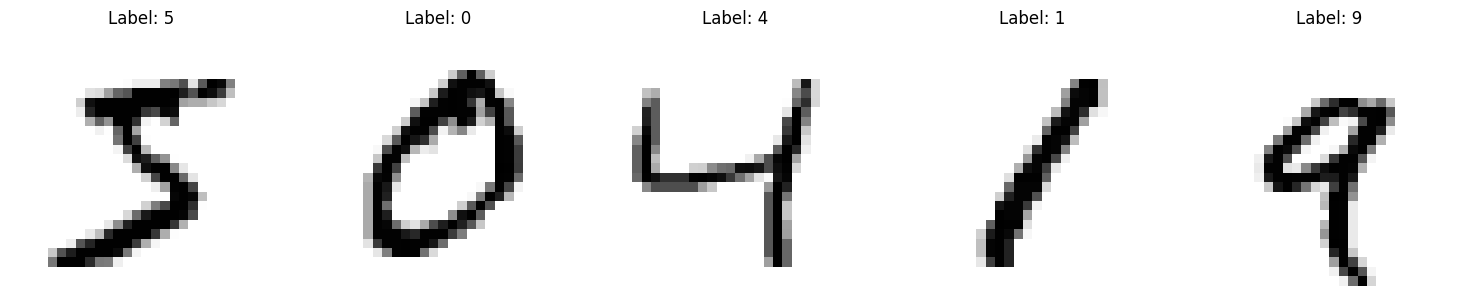

In [9]:
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

for i in range(num_images):
    digit = X[i].reshape(28, 28)        # 784 -> 28x28
    axes[i].imshow(digit, cmap='binary')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# 1. Scale pixels to [0, 1]
X_scaled = X / 255

# 2. One-hot encode the labels into 10 classes
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

print("X_scaled shape:", X_scaled.shape)   # (70000, 784)
print("y_onehot shape:", y_onehot.shape)   # (70000, 10)

X_scaled shape: (70000, 784)
y_onehot shape: (70000, 10)


In [11]:
from sklearn.model_selection import train_test_split

# 3. Split - note we split y_onehot (not the raw string labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=123, shuffle=True
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

X_train: (56000, 784) | y_train: (56000, 10)
X_test:  (14000, 784) | y_test:  (14000, 10)


---
## 6. Sanity Check — Full Forward + Backward Pass

Build a small network, push one batch through, compute the loss, and run the backward pass. Success means: no shape errors, a sensible loss (near $\ln 10 \approx 2.30$ for an untrained 10-class model), and every Dense layer ends up with a `dW`.

In [12]:
model = MLP([Dense(784, 128), Activation(), Dense(128, 10)])
loss_fn = SoftmaxCrossEntropy()

X_batch = X_train[:32]        # a batch of 32 images
y_batch = y_train[:32]

logits = model.forward(X_batch)
loss = loss_fn.forward(logits, y_batch)
dZ = loss_fn.backward()
model.backward(dZ)

print("loss:", loss)
print("logits shape:", logits.shape)                       # (32, 10)
print("first Dense dW shape:", model.layers[0].dW.shape)   # (784, 128)
print("last Dense dW shape: ", model.layers[2].dW.shape)   # (128, 10)

loss: 2.4633683011788188
logits shape: (32, 10)
first Dense dW shape: (784, 128)
last Dense dW shape:  (128, 10)


If the loss prints around 2.3–2.8 and both `dW` shapes are correct, the network runs end to end.

---

## Summary

| Component | Role |
|---|---|
| `Dense` | Linear transform `XW + b`; computes `dW`, `db`, `dX` |
| `Activation` | ReLU nonlinearity; gates the gradient |
| `SoftmaxCrossEntropy` | Loss + the clean `(p − y)` starting gradient |
| `MLP` | Chains layers: forward in order, backward in reverse |

**The key idea:** a uniform `forward`/`backward` interface lets layers stack freely, and `MLP.backward` walking in reverse — each `dX` becoming the next `dZ` — *is* backpropagation through a deep network.

The network now runs a complete forward → loss → backward pass. **Next: the training loop — mini-batches, the parameter update, and training to >97% accuracy on MNIST.**